# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Rakha Makarim | 5054251010 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score, roc_curve, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv('/home/makarim/Desktop/Collage/Machine Learning/Task_ML/NB_LGR/Dataset/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [4]:
df.replace('?', np.nan, inplace=True)
print("\n")
print("Jumlah missing value per kolom:")
print(df.isnull().sum())



Jumlah missing value per kolom:
class                          0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [5]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.

print(df.nunique())

class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   4
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64


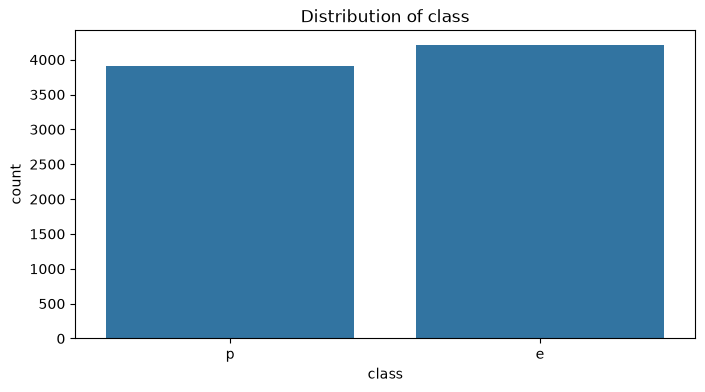

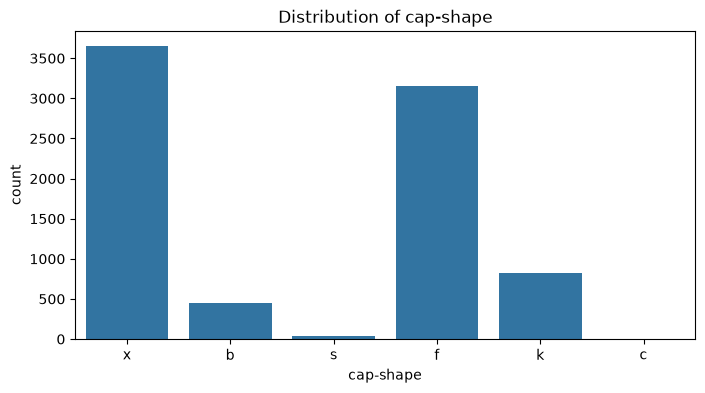

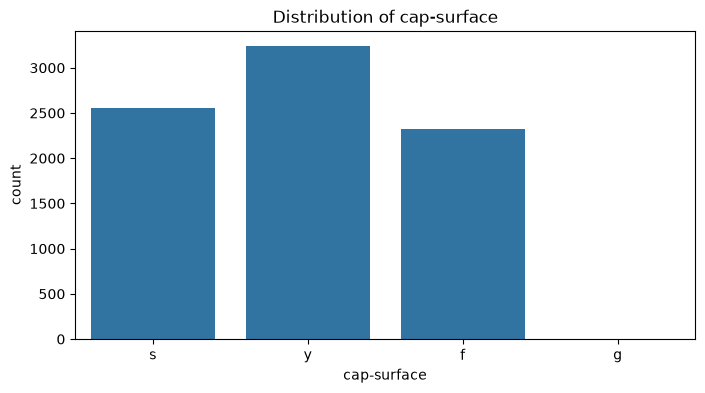

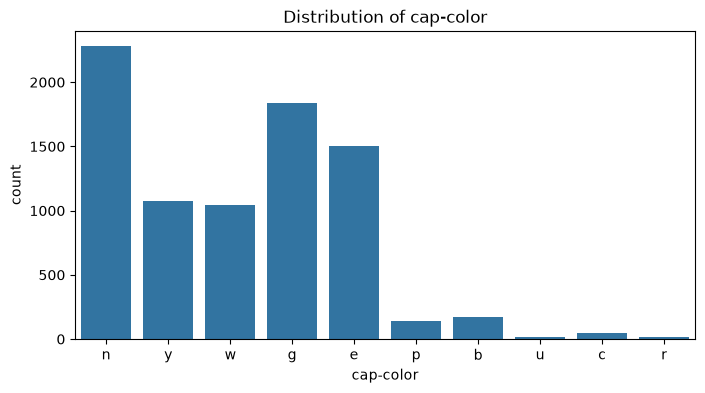

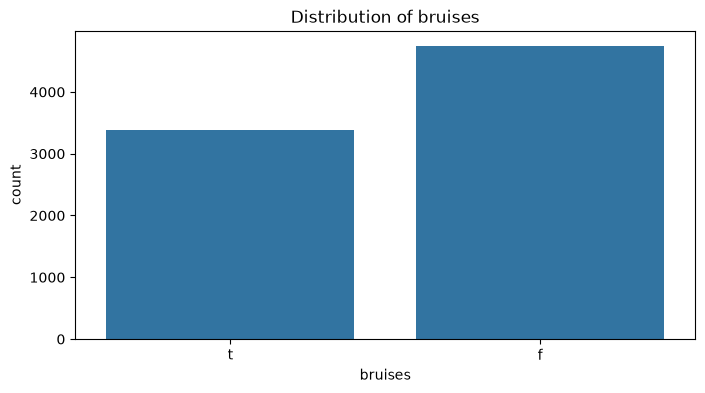

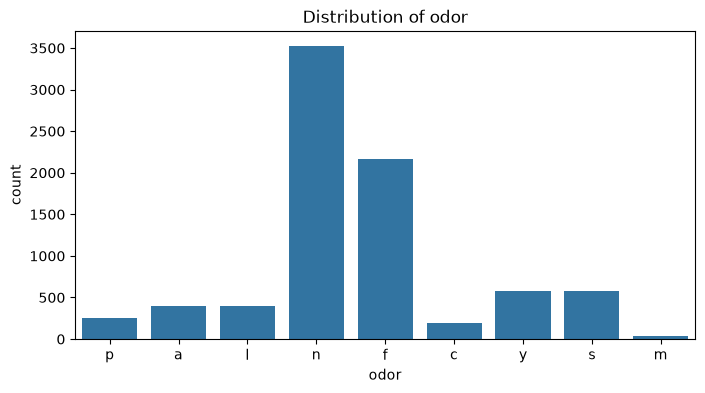

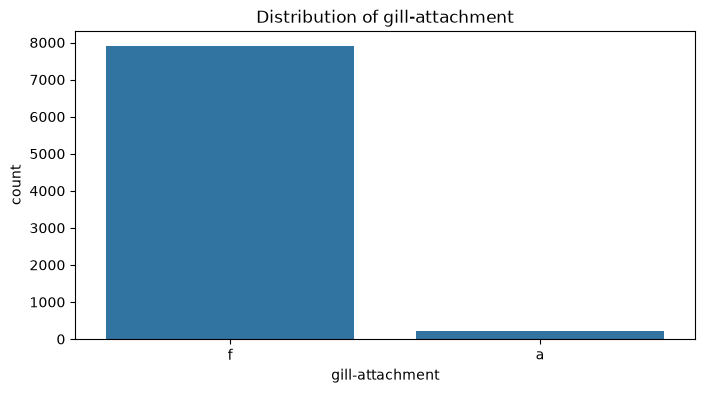

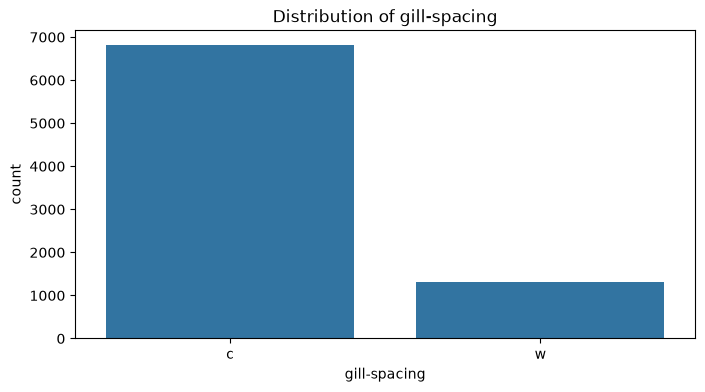

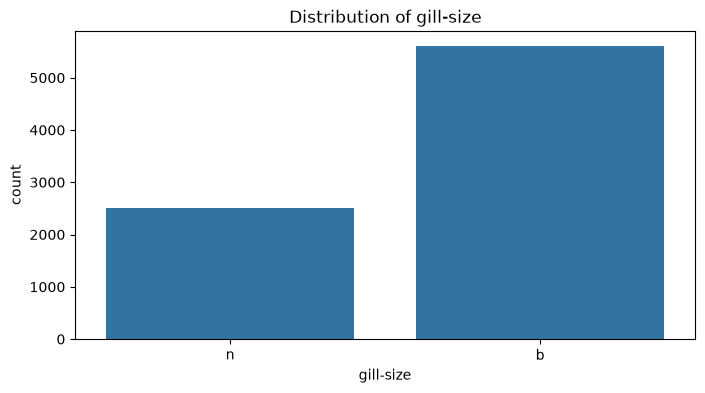

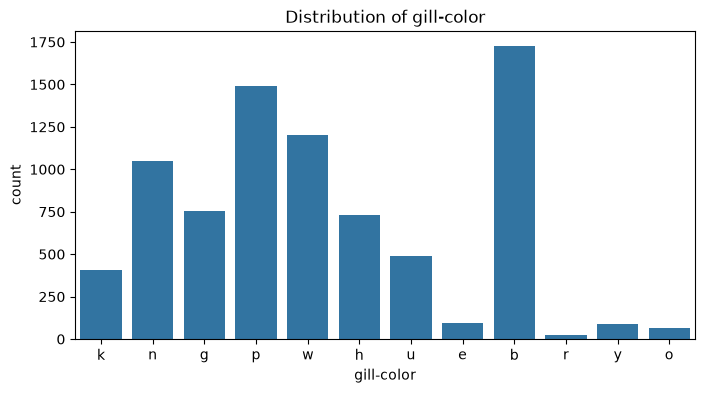

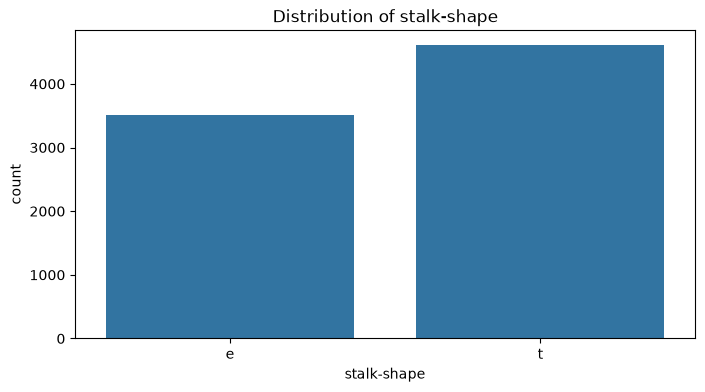

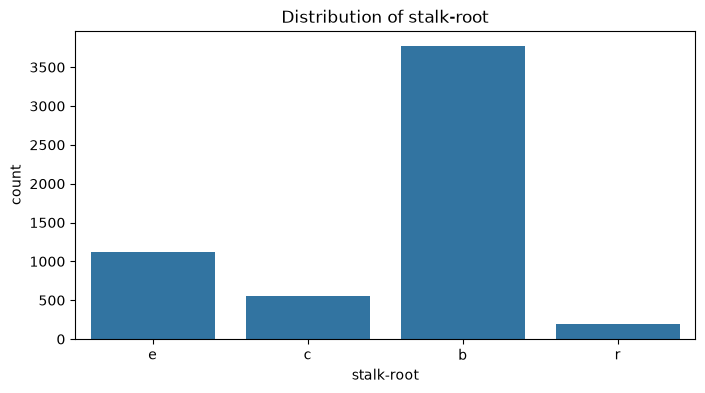

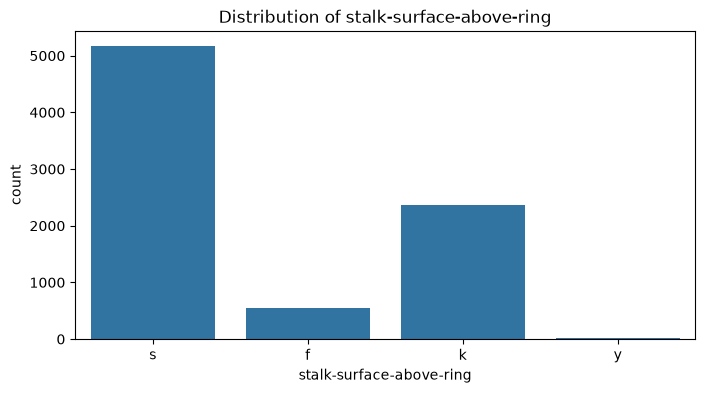

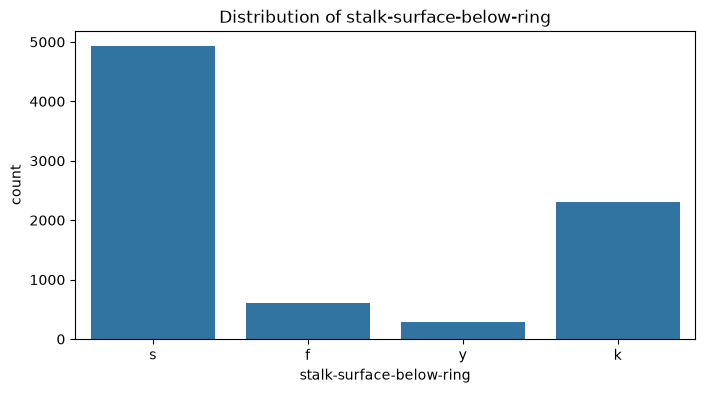

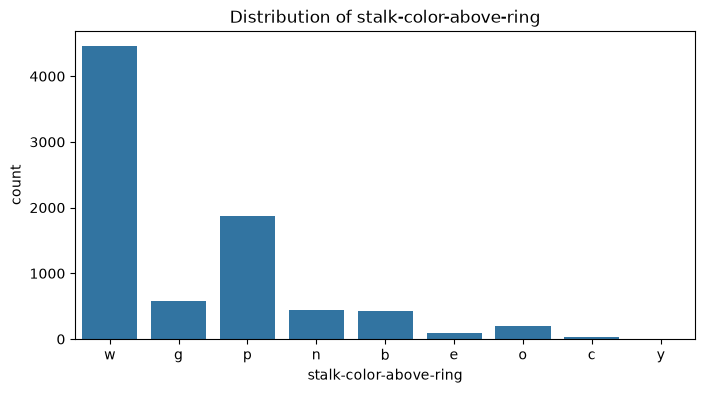

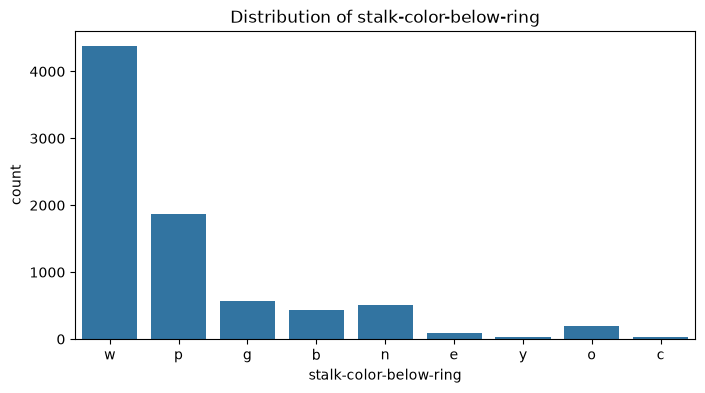

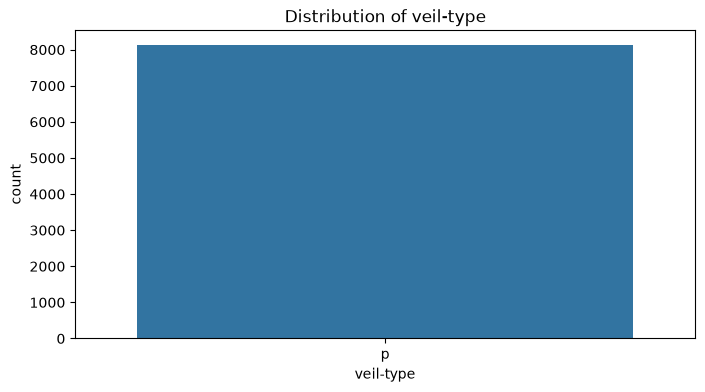

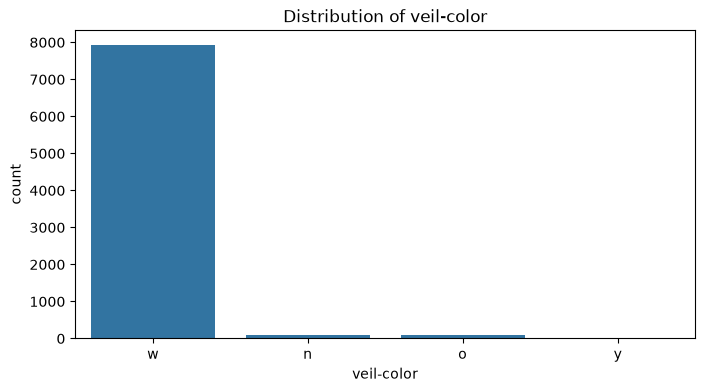

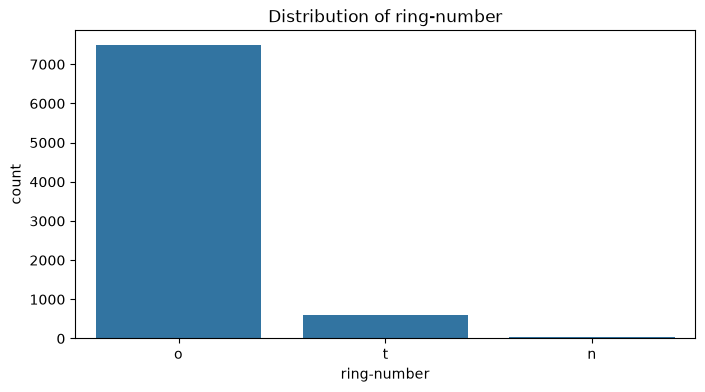

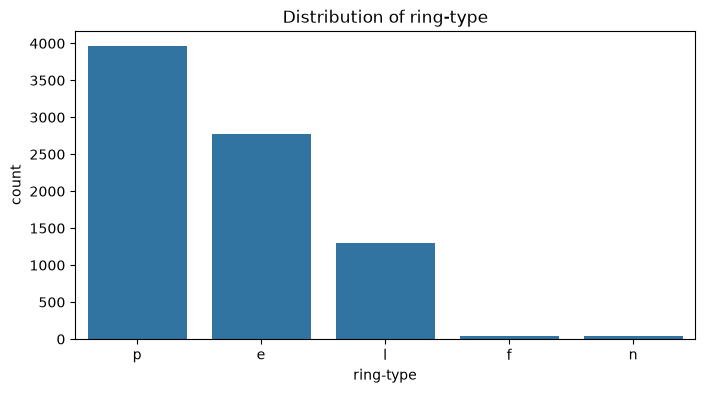

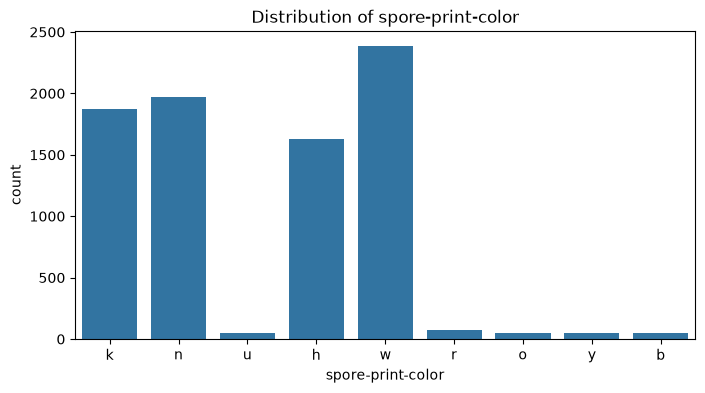

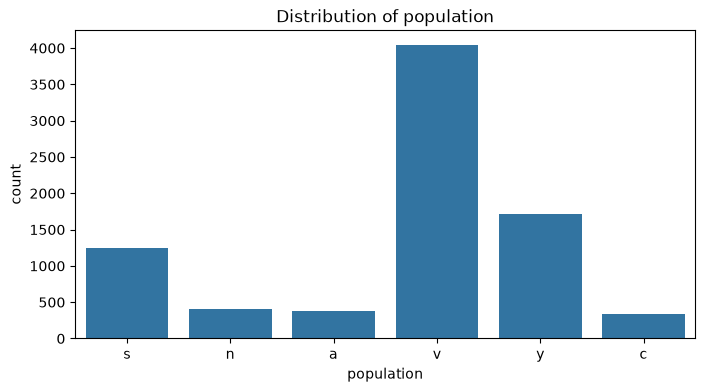

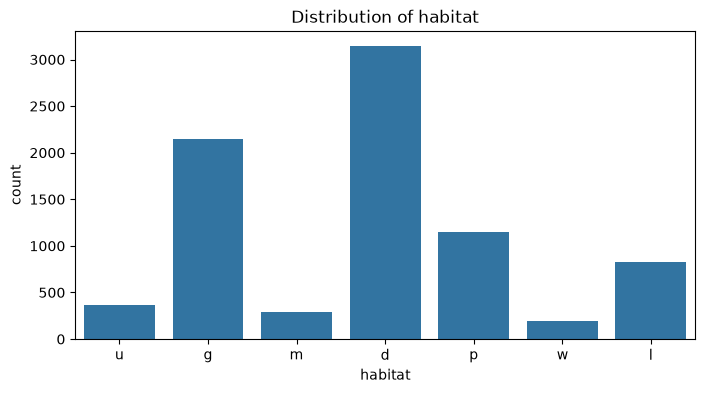

In [6]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

for col in df.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

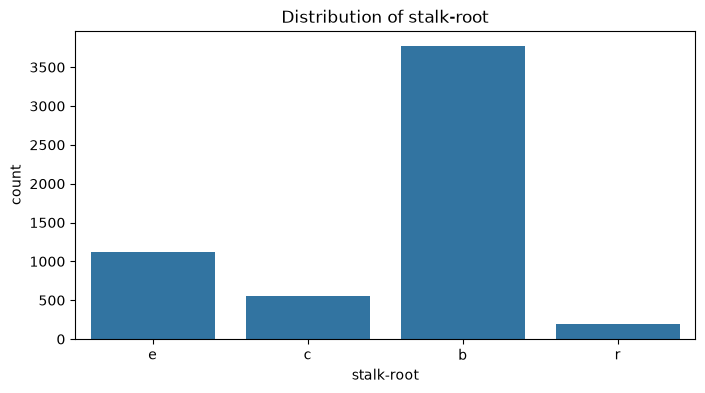

<class 'pandas.Series'>
RangeIndex: 8124 entries, 0 to 8123
Series name: stalk-root
Non-Null Count  Dtype
--------------  -----
5644 non-null   str  
dtypes: str(1)
memory usage: 63.6 KB
stalk-root
b    3776
e    1120
c     556
r     192
Name: count, dtype: int64
5644
2480


In [7]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
plt.figure(figsize=(8, 4))
sns.countplot(x='stalk-root', data=df)
plt.title(f'Distribution of stalk-root')
plt.show()

df['stalk-root'].info()
print(df['stalk-root'].value_counts())
print(df['stalk-root'].value_counts().sum())
print(df['stalk-root'].isnull().sum())

In [8]:
# Mengisi nilai NaN menjadi 'Unknown'
df['stalk-root'] = df['stalk-root'].fillna('Unknown')

In [9]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Fitur {col} hanya memiliki satu nilai unik: {df[col].unique()}. Fitur ini akan di-drop.")
        df.drop(columns=[col], inplace=True)

Fitur veil-type hanya memiliki satu nilai unik: <StringArray>
['p']
Length: 1, dtype: str. Fitur ini akan di-drop.


In [10]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=['class'])
y = df['class'].map({'e': 0, 'p': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [11]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.
oe = OrdinalEncoder()
oe.fit(X_train)
X_train_oe = oe.transform(X_train)
X_test_oe = oe.transform(X_test)

In [12]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.
ohe = OneHotEncoder()
ohe.fit(X_train)
X_train_ohe = ohe.transform(X_train)
X_test_ohe = ohe.transform(X_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [13]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
model = CategoricalNB()
model.fit(X_train_oe, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[-2.33...-0.81964923]]), array([[-0.99...-0.82918638]]), array([[-4.46...-1.75582372]]), array([[-1.06...-1.83577635]]), ...]"


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cg = model.predict(X_test_oe)
y_prob_cg = model.predict_proba(X_test_oe)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [15]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
model = BernoulliNB()
model.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[-2.34,-8.12,-0.97,...,-3.42,-3.73,-3.06], [-4.41,-6.44,-0.93,...,-1.39,-2.65,-8.05]]"


In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bl = model.predict(X_test_ohe)
y_prob_bl = model.predict_proba(X_test_ohe)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [17]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
model = MultinomialNB()
model.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.38,-11.17, -4.02,..., -6.47, -6.77, -6.11], [ -7.46, -9.49, -3.97,..., -4.43, -5.69,-11.1 ]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [18]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_md = model.predict(X_test_ohe)
y_prob_md = model.predict_proba(X_test_ohe)[:, 1]

# 4. Evaluasi Model

In [19]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

met_cg = get_metrics(y_test, y_pred_cg)
met_bl = get_metrics(y_test, y_pred_bl)
met_md = get_metrics(y_test, y_pred_md)

df_eval = pd.DataFrame([met_cg, met_bl, met_md], index=['Categorical', 'Bernouli', 'Multinomial'])
display(df_eval)

,Accuracy,Precision,Recall,F1-Score
Categorical,0.945846,0.990127,0.896552,0.941019
Bernouli,0.932923,0.981429,0.877395,0.926500
Multinomial,0.945846,0.990127,0.896552,0.941019


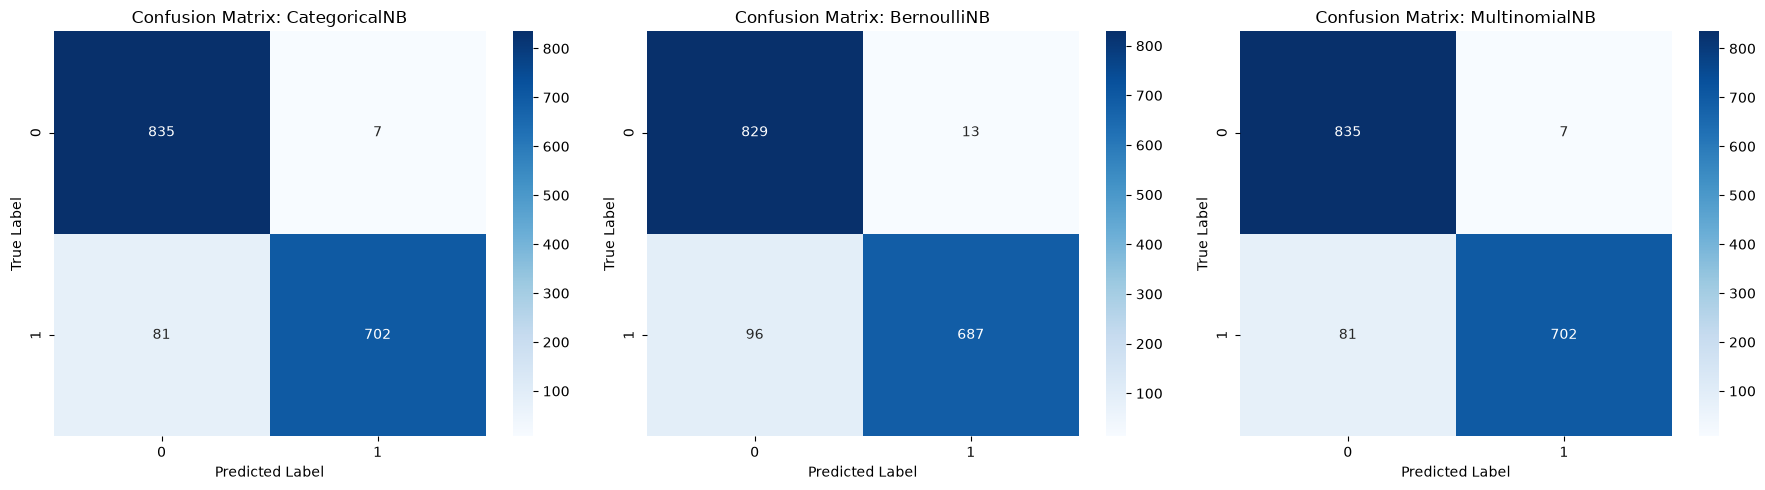

In [20]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
y_pred =[y_pred_cg, y_pred_bl, y_pred_md]
model_names = ['CategoricalNB', 'BernoulliNB', 'MultinomialNB']

for i, (pred, name) in enumerate(zip(y_pred, model_names)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()


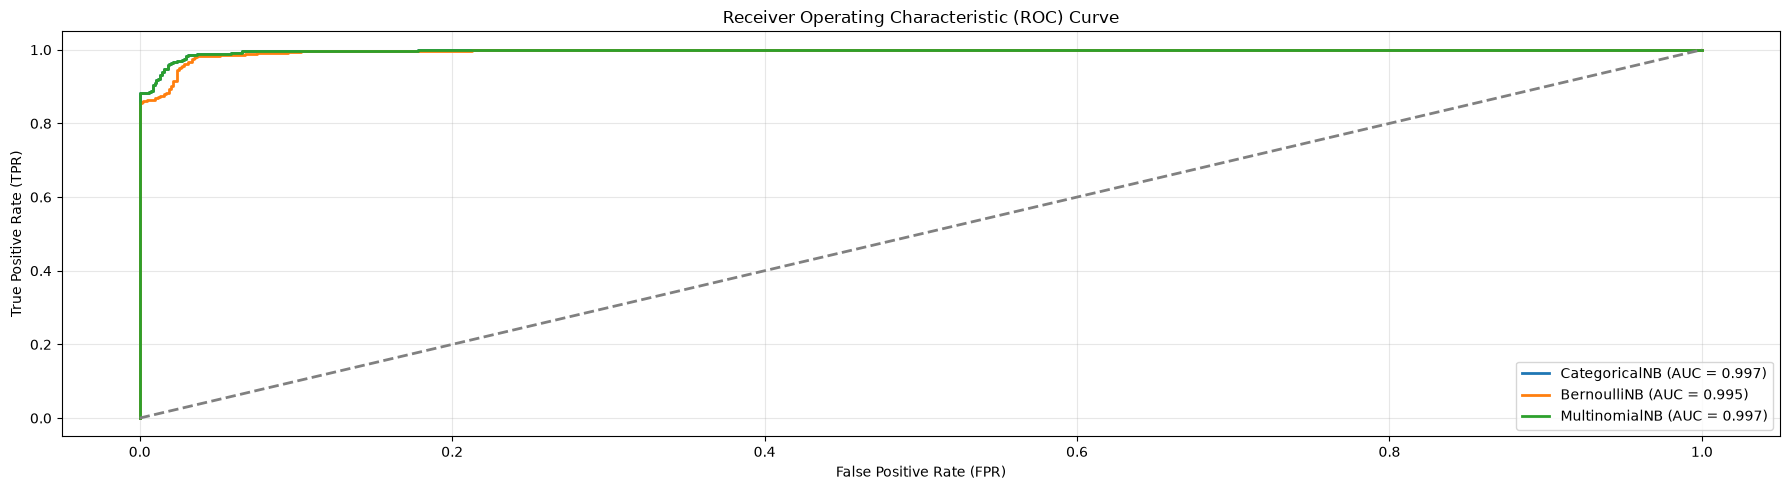

In [21]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
fig, axes = plt.subplots(figsize=(18, 5))
y_prob  =[y_prob_cg, y_prob_bl, y_prob_md]
model_names = ['CategoricalNB', 'BernoulliNB', 'MultinomialNB']

for prob, name in zip(y_prob, model_names):
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc_value = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

CategoricalNB dan MultinomialNB hasilnya sama persis (Acc 0.9458, F1 0.9410, AUC 0.997). BernoulliNB sedikit lebih rendah (Acc 0.9329, F1 0.9265, AUC 0.995).

Categorical dan Multinomial sama karena walau preprocessing-nya beda (ordinal vs one-hot), tiap fitur cuma punya satu kolom aktif di one-hot-nya. Jadi perhitungan probabilitas MultinomialNB ujung-ujungnya setara dengan CategoricalNB, cuma lewat jalur yang beda.

BernoulliNB lebih rendah karena dia juga menghitung kolom yang bernilai 0 (kategori yang tidak muncul), bukan cuma yang aktif. Karena banyak fitur di dataset ini punya banyak kategori, kolom nol jauh lebih dominan dan ikut mempengaruhi hasil, sehingga model lebih sering salah prediksi di kelas poisonous. FN-nya lebih tinggi (96 vs 81), makanya recall dan F1 turun.

Precision ketiga model tinggi (0.98-0.99), jarang salah nebak edible jadi poisonous. Tapi recall lebih rendah (0.87-0.90), ada jamur poisonous yang ke-prediksi edible — ini lebih berisiko karena menyangkut keamanan makan.

# 6. Kesimpulan dan Saran

Dari eksperimen ini, ketiga model Naive Bayes cukup efektif mengklasifikasikan jamur edible vs poisonous, dengan akurasi di atas 93%. CategoricalNB dan MultinomialNB memberikan performa terbaik dan identik (Accuracy 0.9458, F1 0.9410, AUC 0.997), sedangkan BernoulliNB sedikit di bawahnya (Accuracy 0.9329, F1 0.9265, AUC 0.995).

Perbedaan performa ini terkait langsung dengan cara masing-masing model merepresentasikan data. CategoricalNB paling sesuai secara konseptual karena dataset ini memang seluruhnya kategorikal, dan model menghitung probabilitas tiap kategori secara langsung tanpa asumsi tambahan. MultinomialNB, meski dirancang untuk data count, kebetulan menghasilkan hasil yang setara karena struktur one-hot-nya (satu kolom aktif per fitur) membuat perhitungan likelihood-nya ekuivalen dengan CategoricalNB. BernoulliNB sedikit tertinggal karena ikut memperhitungkan ketiadaan kategori lain (kolom bernilai 0), yang menambah noise pada estimasi probabilitas terutama untuk fitur dengan banyak kategori.

Saran untuk eksperimen selanjutnya:

- Coba threshold tuning (bukan default 0.5) untuk menaikkan recall kelas poisonous, karena FN lebih mahal dibanding FP dalam konteks keamanan pangan.
- Bandingkan juga dengan model lain seperti Logistic Regression atau Decision Tree untuk melihat apakah pola serupa (recall lebih rendah dari precision) tetap muncul atau ini karakteristik khusus Naive Bayes.
- Cek feature importance / mutual information tiap fitur terhadap label, untuk tahu fitur mana yang paling berkontribusi pada kesalahan prediksi.
- Untuk BernoulliNB, bisa dicoba binarization threshold yang berbeda atau encoding alternatif untuk melihat apakah gap performanya bisa dikurangi.